# Logistic Regression — Churn Prediction Model

Baseline linear model for churn prediction. Logistic Regression
is fast, interpretable, and gives well-calibrated probabilities.
Needs feature scaling since it's distance-sensitive.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
from imblearn.over_sampling import SMOTE

## 1 · Data Loading & Prep

Dropping features that leak the churn outcome:

| Feature | Why it leaks |
|:--------|:-------------|
| `Total_Net_Paid` | Churned = 0 (didn't pay — set after churn) |
| `price_change_pct/abs` | Derived from Total_Net_Paid |
| `net_paid_vs_last` | Ratio involving current payment (0 for churned) |
| `Payment_Method` | Set to UNKNOWN after churn |
| `Payment_Timeframe` | All churned = 0 |
| `Days_To_Close_Post_Renewal` | Uses close date (post-outcome) |
| `Total_Renewal_Score_New` | Composite encodes outcome |

In [10]:
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

data_path = project_root / "data" / "processed" / "model_ready_dataset.csv"
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. "
        "Make sure you run the notebook from the repo root or run the data prep pipeline first."
    )

df = pd.read_csv(data_path)
print(f"Loaded shape: {df.shape}")

df = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
df["target"] = (df["Prospect_Outcome"] == "Churned").astype(int)
df.drop(columns=["Prospect_Outcome"], inplace=True)

# ---- DROP LEAKY FEATURES ------------------------------------------------
leaky_cols = [
    "Total_Net_Paid", "price_change_pct", "price_change_abs",
    "net_paid_vs_last", "Payment_Method", "Payment_Timeframe",
    "Days_To_Close_Post_Renewal", "Total_Renewal_Score_New",
    "Renewal_Year",
]
cols_before = set(df.columns)
df.drop(columns=leaky_cols, inplace=True, errors="ignore")
actually_dropped = cols_before - set(df.columns)
print(f"Dropped {len(actually_dropped)} leaky/non-predictive features: {sorted(actually_dropped)}")

# --- SPLIT FIRST, THEN ENCODE (fit on train only) -------------------------
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
if cat_cols:
    ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train.loc[:, cat_cols] = ord_enc.fit_transform(X_train[cat_cols]).astype(float)
    X_test.loc[:, cat_cols] = ord_enc.transform(X_test[cat_cols]).astype(float)

# Ensure all columns are numeric
X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)

# --- SMOTE: oversample the minority class on TRAINING data only ----
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(f"After SMOTE -> Train: {X_train.shape[0]}  (Churn: {y_train.mean():.2%})")

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Churn rate: {y_train.mean():.2%}")

Loaded shape: (122082, 61)
Dropped 9 leaky/non-predictive features: ['Days_To_Close_Post_Renewal', 'Payment_Method', 'Payment_Timeframe', 'Renewal_Year', 'Total_Net_Paid', 'Total_Renewal_Score_New', 'net_paid_vs_last', 'price_change_abs', 'price_change_pct']
After SMOTE -> Train: 161962  (Churn: 50.00%)

Features: 51
Train: 161962, Test: 22779
Churn rate: 50.00%


## 2 · Baseline Logistic Regression

Using a Pipeline with StandardScaler + LogisticRegression.
The scaler is fit inside the pipeline to avoid data leakage
during cross-validation.

In [11]:
lr_pipe_base = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
lr_pipe_base.fit(X_train, y_train)

y_pred_base = lr_pipe_base.predict(X_test)
y_prob_base = lr_pipe_base.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "F1 Score": f1_score(y_test, y_pred_base),
    "ROC AUC": roc_auc_score(y_test, y_prob_base),
}

print("=" * 60)
print("BASELINE LOGISTIC REGRESSION RESULTS")
print("=" * 60)
for k, v in baseline_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=["Won", "Churned"]))

BASELINE LOGISTIC REGRESSION RESULTS
Accuracy  : 0.8909
Precision : 0.5056
Recall    : 0.8571
F1 Score  : 0.6360
ROC AUC   : 0.9529

              precision    recall  f1-score   support

         Won       0.98      0.90      0.94     20245
     Churned       0.51      0.86      0.64      2534

    accuracy                           0.89     22779
   macro avg       0.74      0.88      0.79     22779
weighted avg       0.93      0.89      0.90     22779



## 3 · Hyperparameter Tuning

Testing different regularization strengths (C) and solvers.
LR is very fast so this runs in seconds.
Scaler is inside the Pipeline so each CV fold fits its own scaler.

In [12]:
configs = [
    {"C": 0.01, "solver": "lbfgs", "penalty": "l2"},
    {"C": 0.1,  "solver": "lbfgs", "penalty": "l2"},
    {"C": 1.0,  "solver": "lbfgs", "penalty": "l2"},
    {"C": 10.0, "solver": "lbfgs", "penalty": "l2"},
    {"C": 0.1,  "solver": "liblinear", "penalty": "l1"},
    {"C": 1.0,  "solver": "liblinear", "penalty": "l1"},
    {"C": 10.0, "solver": "liblinear", "penalty": "l1"},
]

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
best_f1 = 0
best_config = None

for i, cfg in enumerate(configs):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(**cfg, class_weight="balanced", max_iter=1000, random_state=42)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_strat, scoring="f1")
    mean_f1 = scores.mean()
    print(f"Config {i+1}: F1={mean_f1:.4f} (+/- {scores.std():.4f})  C={cfg['C']}, {cfg['penalty']}, {cfg['solver']}")
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_config = cfg

print(f"\nBest: {best_config}  ->  F1={best_f1:.4f}")

Config 1: F1=0.9029 (+/- 0.0004)  C=0.01, l2, lbfgs
Config 2: F1=0.9043 (+/- 0.0002)  C=0.1, l2, lbfgs
Config 3: F1=0.9049 (+/- 0.0003)  C=1.0, l2, lbfgs
Config 4: F1=0.9049 (+/- 0.0003)  C=10.0, l2, lbfgs
Config 5: F1=0.9047 (+/- 0.0002)  C=0.1, l1, liblinear
Config 6: F1=0.9048 (+/- 0.0002)  C=1.0, l1, liblinear
Config 7: F1=0.9048 (+/- 0.0002)  C=10.0, l1, liblinear

Best: {'C': 10.0, 'solver': 'lbfgs', 'penalty': 'l2'}  ->  F1=0.9049


## 4 · Best Model Evaluation

In [13]:
# guard: fallback if tuning cell wasn't run
if best_config is None or not isinstance(best_config, dict):
    warnings.warn("best_config not found — using baseline defaults.")
    best_config = {"C": 1.0, "solver": "lbfgs", "penalty": "l2"}

best_lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(**best_config, class_weight="balanced", max_iter=1000, random_state=42)),
])
best_lr_pipe.fit(X_train, y_train)

y_pred = best_lr_pipe.predict(X_test)
y_prob = best_lr_pipe.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_prob),
}

print("=" * 60)
print("TUNED LOGISTIC REGRESSION RESULTS")
print("=" * 60)
for k, v in tuned_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Won", "Churned"]))

TUNED LOGISTIC REGRESSION RESULTS
Accuracy  : 0.8910
Precision : 0.5058
Recall    : 0.8560
F1 Score  : 0.6359
ROC AUC   : 0.9528

              precision    recall  f1-score   support

         Won       0.98      0.90      0.94     20245
     Churned       0.51      0.86      0.64      2534

    accuracy                           0.89     22779
   macro avg       0.74      0.88      0.79     22779
weighted avg       0.93      0.89      0.90     22779



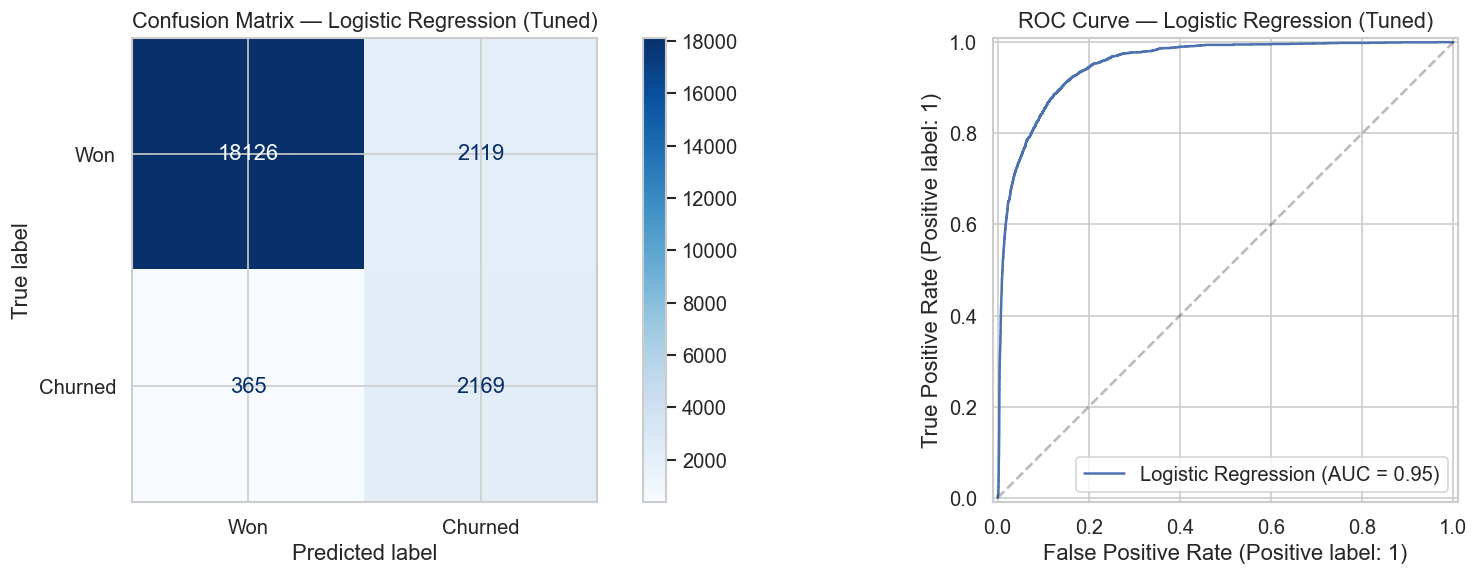

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Won", "Churned"], ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("Confusion Matrix — Logistic Regression (Tuned)", fontsize=13)

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name="Logistic Regression")
axes[1].set_title("ROC Curve — Logistic Regression (Tuned)", fontsize=13)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.show()

## 5 · Feature Coefficients

Unlike tree models, LR gives us coefficients — positive = pushes
toward churn, negative = pushes toward retention.

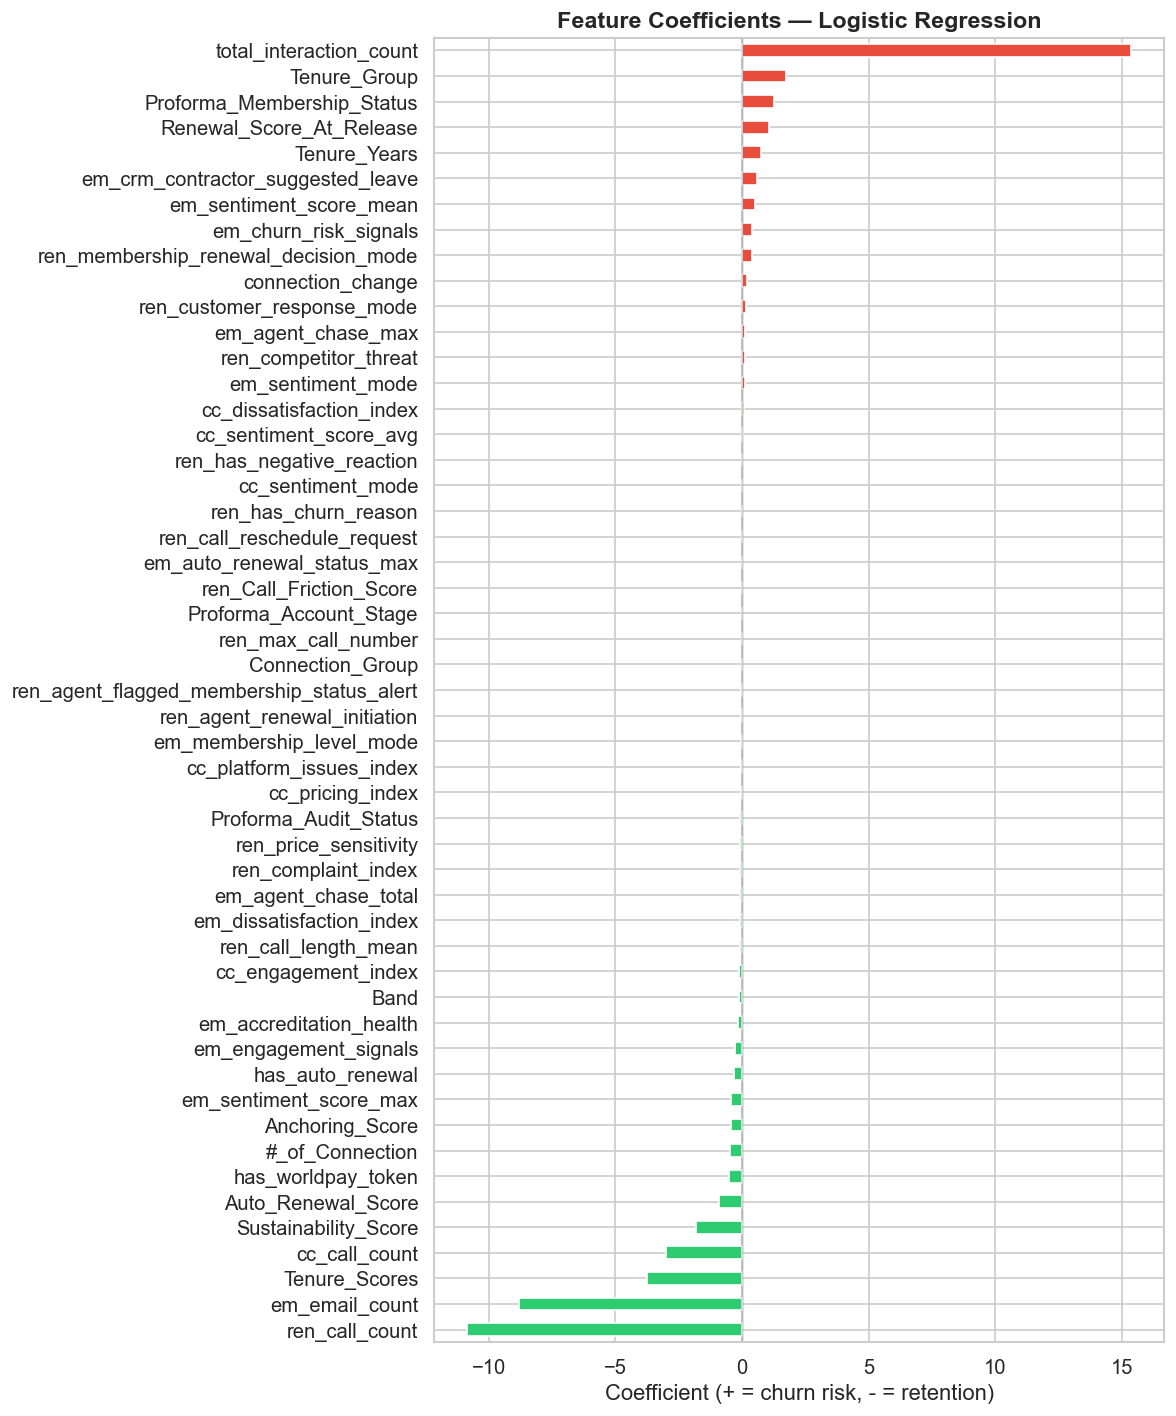

In [15]:
best_lr = best_lr_pipe.named_steps["lr"]

coefs = pd.Series(best_lr.coef_[0], index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 12))

colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in coefs.values]
coefs.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set_title("Feature Coefficients — Logistic Regression", fontsize=14, fontweight="bold")
ax.set_xlabel("Coefficient (+ = churn risk, - = retention)")
ax.axvline(x=0, color="gray", linestyle="-", alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

In [16]:
summary = pd.DataFrame({"Baseline": baseline_metrics, "Tuned": tuned_metrics})
summary = summary.round(4)
try:
    print(summary.to_markdown())
except ImportError:
    print(summary.to_string())

|           |   Baseline |   Tuned |
|:----------|-----------:|--------:|
| Accuracy  |     0.8909 |  0.891  |
| Precision |     0.5056 |  0.5058 |
| Recall    |     0.8571 |  0.856  |
| F1 Score  |     0.636  |  0.6359 |
| ROC AUC   |     0.9529 |  0.9528 |
